# Stock Direction Prediction -- Walk-Forward Validation

`Stock Direction Pred.ipynb` judged the model on one fixed 45-day test slice. That's a single sample of "how did the model do this one time" -- not enough to tell a real edge from a lucky/unlucky stretch, especially since the baselines it needs to beat can themselves swing 20+ points between windows (persistence hit 57.8% for UNTR but only 37.8% for ASII, purely from how much each test window happened to trend).

This notebook repeats the same train/val/test process across **multiple rolling windows** (expanding training set, walking forward through time) instead of one split, and reports the average and spread across folds -- the standard fix for judging a time-series model on more than one lucky/unlucky period.

No sentiment features here (by design, per the last few notebooks) -- same lag/calendar features and baselines as `Stock Direction Pred.ipynb`, just scored across many windows instead of one.

**Reusable across tickers**: set `TICKER` below to any symbol in `data/prices/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score

In [2]:
TICKER = "UNTR"  # any of: ASII, AALI, UNTR, AUTO, ACST, MPMX, TURI

df = pd.read_csv(f"../data/prices/{TICKER}.csv")
df_close = df[["Date", "Close"]].copy()
df_close.index = pd.to_datetime(df_close["Date"], format="%Y-%m-%d")
df_close = df_close.drop(columns="Date")

print(f"{TICKER}: {df_close.index.min().date()} to {df_close.index.max().date()} ({len(df_close)} trading days)")

UNTR: 2025-09-26 to 2026-09-25 (244 trading days)


## Feature engineering (identical to `Stock Direction Pred.ipynb`)

In [3]:
df_close["dayofweek"] = df_close.index.dayofweek

df_close["ret"] = df_close["Close"].pct_change()
df_close["ret_lag1"] = df_close["ret"].shift(1)
df_close["ret_lag2"] = df_close["ret"].shift(2)
df_close["ret_lag3"] = df_close["ret"].shift(3)
df_close["ret_lag5"] = df_close["ret"].shift(5)
df_close["vol_5"] = df_close["ret"].shift(1).rolling(5).std()

df_close["direction"] = (df_close["ret"] > 0).astype(int)

FEATURES = ["ret_lag1", "ret_lag2", "ret_lag3", "ret_lag5", "vol_5", "dayofweek"]
TARGET = "direction"

data = df_close.dropna(subset=FEATURES + [TARGET])
print(f"Usable rows after dropping lag-feature NaNs: {len(data)}")

Usable rows after dropping lag-feature NaNs: 238


## Walk-forward folds

**Expanding window**: fold *k*'s training set is everything chronologically before that fold's test window (never data from the future relative to that fold), so each fold is exactly as leak-free as the single-split version -- there's just more of them. Validation for early stopping is carved from the end of each fold's training set, same as before.

`MIN_TRAIN_SIZE` guards against a first fold trained on too little data to mean anything; `FOLD_TEST_SIZE` is deliberately smaller than the single-split version's 45 days so there's room for several folds instead of one.

In [4]:
MIN_TRAIN_SIZE = 100
VAL_SIZE = 15
FOLD_TEST_SIZE = 25

folds = []
test_start = MIN_TRAIN_SIZE
while test_start + FOLD_TEST_SIZE <= len(data):
    folds.append((test_start, test_start + FOLD_TEST_SIZE))
    test_start += FOLD_TEST_SIZE

print(f"{len(folds)} folds, {FOLD_TEST_SIZE} test days each ({len(folds) * FOLD_TEST_SIZE} test predictions total)")
for i, (s, e) in enumerate(folds):
    print(f"  fold {i}: train rows 0:{s - VAL_SIZE}, val {s - VAL_SIZE}:{s}, test {s}:{e} "
          f"({data.index[s].date()} to {data.index[e - 1].date()})")

5 folds, 25 test days each (125 test predictions total)
  fold 0: train rows 0:85, val 85:100, test 100:125 (2026-03-04 to 2026-04-15)
  fold 1: train rows 0:110, val 110:125, test 125:150 (2026-04-16 to 2026-05-21)
  fold 2: train rows 0:135, val 135:150, test 150:175 (2026-05-22 to 2026-06-29)
  fold 3: train rows 0:160, val 160:175, test 175:200 (2026-06-30 to 2026-08-03)
  fold 4: train rows 0:185, val 185:200, test 200:225 (2026-08-04 to 2026-09-08)


## Run every fold: persistence, majority-class, and the model

In [5]:
results = []
daily_records = []

for i, (test_start, test_end) in enumerate(folds):
    train_full = data.iloc[:test_start]
    val = train_full.iloc[-VAL_SIZE:]
    train = train_full.iloc[:-VAL_SIZE]
    test = data.iloc[test_start:test_end]

    # Persistence: predict test day's direction = previous day's actual direction
    persistence_pred = df_close[TARGET].shift(1).loc[test.index]
    persistence_acc = accuracy_score(test[TARGET], persistence_pred)

    # Majority class from this fold's TRAIN only
    majority_class = train[TARGET].mode()[0]
    majority_acc = accuracy_score(test[TARGET], np.full(len(test), majority_class))

    clf = xgb.XGBClassifier(
        n_estimators=1000,
        early_stopping_rounds=50,
        learning_rate=0.01,
        max_depth=3,
        eval_metric="logloss",
    )
    clf.fit(train[FEATURES], train[TARGET],
            eval_set=[(train[FEATURES], train[TARGET]), (val[FEATURES], val[TARGET])],
            verbose=False)

    pred = clf.predict(test[FEATURES])
    proba = clf.predict_proba(test[FEATURES])[:, 1]
    model_acc = accuracy_score(test[TARGET], pred)
    # ROC-AUC is undefined when a fold's test set is all one class -- skip it for that fold.
    model_auc = roc_auc_score(test[TARGET], proba) if test[TARGET].nunique() > 1 else np.nan

    results.append({
        "fold": i,
        "test_start": test.index.min().date(),
        "test_end": test.index.max().date(),
        "n_train": len(train),
        "test_up_rate": test[TARGET].mean(),
        "persistence_acc": persistence_acc,
        "majority_acc": majority_acc,
        "model_acc": model_acc,
        "model_auc": model_auc,
        "best_iteration": clf.best_iteration,
    })

    # Per-day predictions, kept for the pred-vs-actual visualization and P&L backtest below.
    for date, actual, predicted, p_up in zip(test.index, test[TARGET].values, pred, proba):
        daily_records.append({
            "date": date,
            "fold": i,
            "close": df_close.loc[date, "Close"],
            "ret": df_close.loc[date, "ret"],
            "actual_direction": actual,
            "predicted_direction": predicted,
            "persistence_direction": int(persistence_pred.loc[date]),
            "p_up": p_up,
            "correct": actual == predicted,
        })

results_df = pd.DataFrame(results)
daily_df = pd.DataFrame(daily_records).set_index("date")
results_df

,fold,test_start,test_end,n_train,test_up_rate,persistence_acc,majority_acc,model_acc,model_auc,best_iteration
0,0,2026-03-04,2026-04-15,85,0.52,0.36,0.52,0.52,0.631410,0
1,1,2026-04-16,2026-05-21,110,0.28,0.56,0.28,0.28,0.357143,60
2,2,2026-05-22,2026-06-29,135,0.36,0.60,0.36,0.36,0.593750,3
3,3,2026-06-30,2026-08-03,160,0.32,0.68,0.68,0.68,0.794118,0
4,4,2026-08-04,2026-09-08,185,0.56,0.48,0.44,0.40,0.438312,2


## Aggregate across folds -- the number that actually matters

In [6]:
summary = results_df[["persistence_acc", "majority_acc", "model_acc"]].agg(["mean", "std"])
print(f"{TICKER} -- {len(folds)} folds, {FOLD_TEST_SIZE} test days each\n")
print(summary.to_string())
print()

wins = (results_df["model_acc"] > results_df[["persistence_acc", "majority_acc"]].max(axis=1)).sum()
ties = (results_df["model_acc"] == results_df[["persistence_acc", "majority_acc"]].max(axis=1)).sum()
losses = len(results_df) - wins - ties
print(f"Model beat BOTH baselines in {wins}/{len(folds)} folds, tied the best baseline in {ties}, lost in {losses}")
print(f"Mean ROC-AUC across folds: {results_df['model_auc'].mean():.3f}  (0.5 = coin flip)")

UNTR -- 5 folds, 25 test days each

      persistence_acc  majority_acc  model_acc
mean         0.536000      0.456000   0.448000
std          0.121984      0.153883   0.155949

Model beat BOTH baselines in 0/5 folds, tied the best baseline in 2, lost in 3
Mean ROC-AUC across folds: 0.563  (0.5 = coin flip)


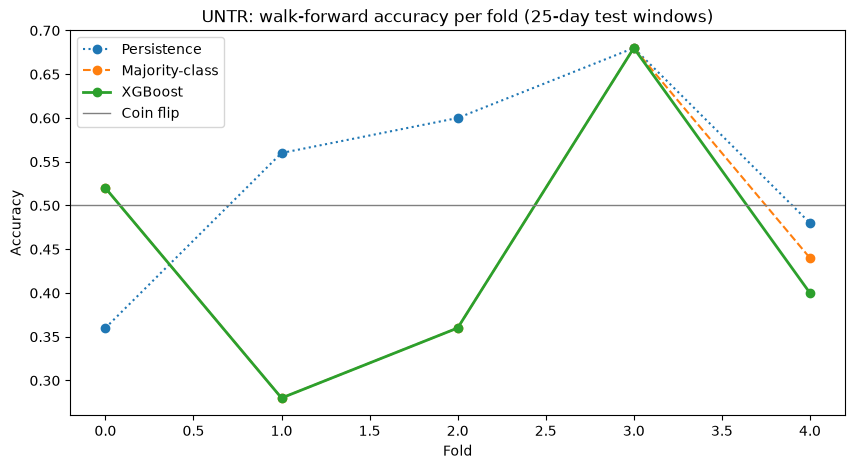

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
x = results_df["fold"]
ax.plot(x, results_df["persistence_acc"], marker="o", label="Persistence", linestyle=":")
ax.plot(x, results_df["majority_acc"], marker="o", label="Majority-class", linestyle="--")
ax.plot(x, results_df["model_acc"], marker="o", label="XGBoost", linewidth=2)
ax.axhline(0.5, color="gray", linewidth=1, label="Coin flip")
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_title(f"{TICKER}: walk-forward accuracy per fold ({FOLD_TEST_SIZE}-day test windows)")
ax.legend()
plt.show()

## Reading this result

UNTR, 5 folds of 25 test days each (125 predictions total): **model beat both baselines in 0/5 folds, tied the best baseline in 2, and lost outright in 3.** Mean accuracy: persistence 53.6%, majority-class 45.6%, model 44.8% -- the model's *average* is actually the worst of the three. Mean ROC-AUC across folds: 0.563, barely above the 0.5 coin-flip line.

This is a much stronger, more honest answer than the single-split notebook gave. That one showed the model losing to both baselines on one 45-day window and left open whether that was just an unlucky stretch. Across 5 independent windows spanning March-September 2026, the model never once beat both baselines simultaneously -- 0/5 is about as clear a "no edge" result as walk-forward validation can produce. `best_iteration` bouncing between 0 and 60 across folds also shows the model's behavior is unstable fold-to-fold, not converging on some real pattern it just needs more data to sharpen.

`test_up_rate` swings from 28% to 56% across folds -- confirming the earlier suspicion that a single-split test's baseline strength is mostly luck of which regime that window happened to land in, not a stable property of the stock. The takeaway holds regardless: for UNTR, daily direction from its own recent price history shows no exploitable signal, and this is now backed by 5 out-of-sample windows instead of 1.

## Predicted vs. Actual: Walking Through Every Test Day

Concatenates every fold's test-day predictions into one timeline (all walk-forward test windows back to back) so you can see where the model's calls actually landed against the real price move, not just the summary accuracy number.

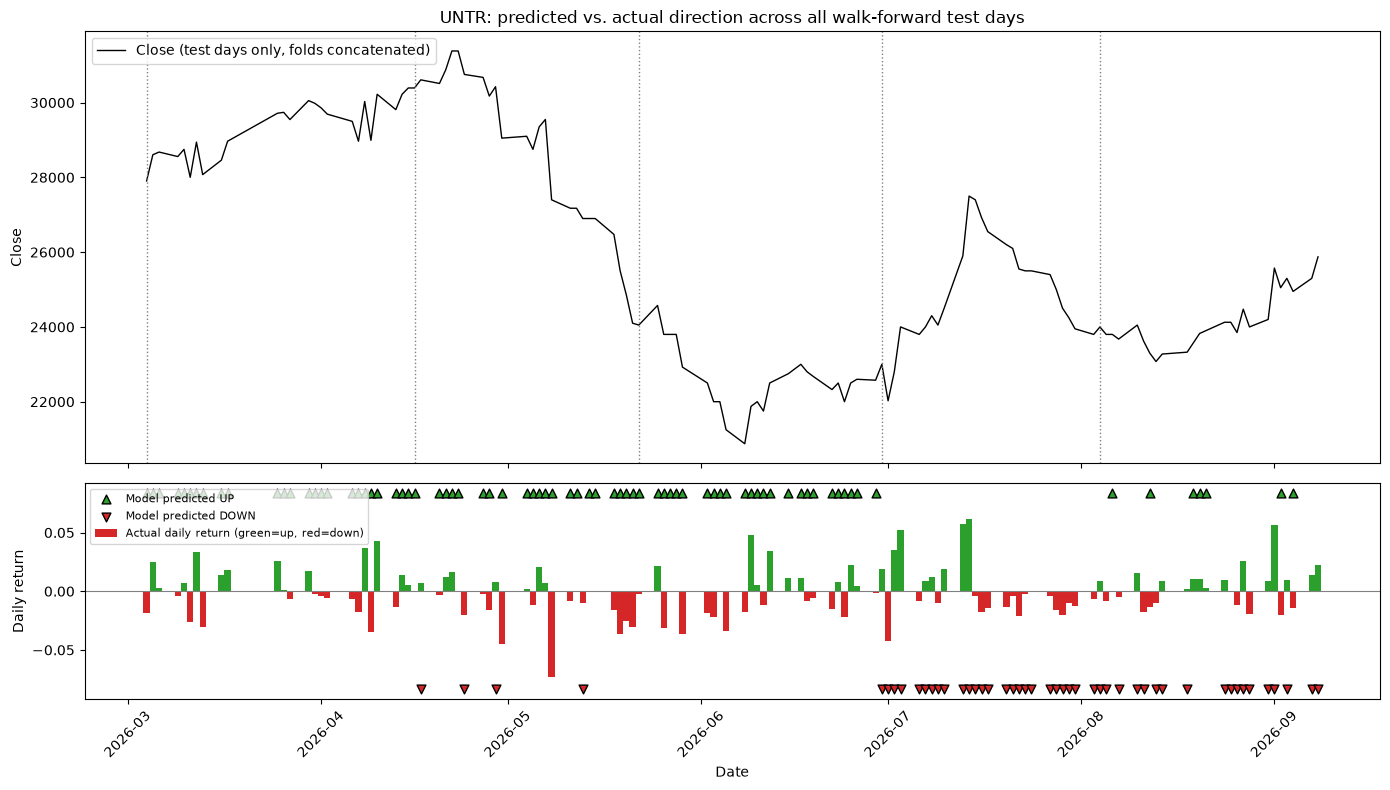

Overall accuracy across all 125 walk-forward test days: 44.8%
Wrong calls: 69 / 125


In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

# --- Top: actual close price across the full walk-forward test span ---
ax1.plot(daily_df.index, daily_df["close"], color="black", linewidth=1, label="Close (test days only, folds concatenated)")
for fold_start in daily_df.groupby("fold")["fold"].first().index:
    fold_dates = daily_df.index[daily_df["fold"] == fold_start]
    ax1.axvline(fold_dates.min(), color="gray", linestyle=":", linewidth=1)
ax1.set_ylabel("Close")
ax1.set_title(f"{TICKER}: predicted vs. actual direction across all walk-forward test days")
ax1.legend(loc="upper left")

# --- Bottom: actual direction (bar) vs model's predicted direction (marker) ---
colors = daily_df["actual_direction"].map({1: "#2ca02c", 0: "#d62728"})
ax2.bar(daily_df.index, daily_df["ret"], color=colors, width=1.0, label="Actual daily return (green=up, red=down)")

up_pred = daily_df[daily_df["predicted_direction"] == 1]
down_pred = daily_df[daily_df["predicted_direction"] == 0]
ax2.scatter(up_pred.index, [daily_df["ret"].abs().max() * 1.15] * len(up_pred),
            marker="^", color="#2ca02c", edgecolor="black", s=40, label="Model predicted UP")
ax2.scatter(down_pred.index, [-daily_df["ret"].abs().max() * 1.15] * len(down_pred),
            marker="v", color="#d62728", edgecolor="black", s=40, label="Model predicted DOWN")

ax2.axhline(0, color="gray", linewidth=0.8)
ax2.set_ylabel("Daily return")
ax2.set_xlabel("Date")
ax2.legend(loc="upper left", fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

acc = daily_df["correct"].mean()
print(f"Overall accuracy across all {len(daily_df)} walk-forward test days: {acc:.1%}")
print(f"Wrong calls: {(~daily_df['correct']).sum()} / {len(daily_df)}")

**Reading this chart**: the bar's color is what *actually* happened that day (green=up, red=down); the triangle above/below is what the model *predicted*. When a green bar has an up-triangle above it (or a red bar has a down-triangle below it), that's a correct call — matching colors/positions. A green bar with a down-triangle (or vice versa) is a miss. Scan for whether misses cluster in particular folds (visible via the dotted vertical fold-boundary lines in the top panel) — that's the same "one good fold carrying the average" pattern the fold table already flagged, just visible day-by-day instead of as one aggregate number per fold.

## P&L Backtest: Does Being Right More Often Make Money?

Accuracy answers "was the direction call correct." It doesn't answer "would this have made money" -- a model can be right 55% of the time and still lose, if it's wrong on the days that move the most, or if trading costs eat the edge. This section turns the walk-forward predictions into an actual simplified trading simulation.

**Rule**: go **long** (hold the stock) on any day the model predicts UP, stay **flat** (cash, 0% that day) on any day it predicts DOWN. No shorting -- realistic for a retail IDX account, and it isolates "does the model add value" without also betting the DOWN calls are exploitable.

**Transaction cost assumption**: 0.15% (15 bps) charged whenever the position changes from the previous day (flat->long or long->flat) -- a rough stand-in for real IDX brokerage fees, not pulled from an actual fee schedule. This is deliberately a simplification, not investment advice -- real slippage, bid-ask spread, and fee tiers vary by broker.

Compared against two things: **buy-and-hold** (ignore the model entirely, just hold the stock the whole test span) and the same long/flat rule driven by **persistence** instead of the model -- so "does the model's signal beat doing nothing" and "does the model's signal beat the dumbest possible signal" are both answered directly.

In [9]:
COST_PER_TRADE = 0.0015  # 15 bps, charged on any day the position changes

def simulate(position):
    """position: 1=long that day, 0=flat. Returns daily strategy return after cost."""
    position = position.reindex(daily_df.index)
    trade = position.diff().fillna(position.iloc[0]).abs()  # first day counts as entering from flat
    strategy_ret = position * daily_df["ret"] - trade * COST_PER_TRADE
    return strategy_ret, trade


model_position = daily_df["predicted_direction"]
persistence_position = daily_df["persistence_direction"]
buyhold_position = pd.Series(1, index=daily_df.index)

model_ret, model_trades = simulate(model_position)
persistence_ret, persistence_trades = simulate(persistence_position)
buyhold_ret, buyhold_trades = simulate(buyhold_position)

curves = pd.DataFrame({
    "Model (long/flat)": (1 + model_ret).cumprod(),
    "Persistence (long/flat)": (1 + persistence_ret).cumprod(),
    "Buy & hold": (1 + buyhold_ret).cumprod(),
})


def summarize(name, ret, trades):
    cum = (1 + ret).cumprod()
    total_return = cum.iloc[-1] - 1
    running_max = cum.cummax()
    max_drawdown = (cum / running_max - 1).min()
    sharpe = (ret.mean() / ret.std()) * np.sqrt(252) if ret.std() > 0 else np.nan
    return {
        "strategy": name,
        "total_return": total_return,
        "max_drawdown": max_drawdown,
        "sharpe_like": sharpe,
        "n_trades": int(trades.sum()),
        "total_cost_paid": trades.sum() * COST_PER_TRADE,
    }


summary = pd.DataFrame([
    summarize("Model (long/flat)", model_ret, model_trades),
    summarize("Persistence (long/flat)", persistence_ret, persistence_trades),
    summarize("Buy & hold", buyhold_ret, buyhold_trades),
]).set_index("strategy")

summary["total_return"] = summary["total_return"].map(lambda x: f"{x:.1%}")
summary["max_drawdown"] = summary["max_drawdown"].map(lambda x: f"{x:.1%}")
summary["sharpe_like"] = summary["sharpe_like"].map(lambda x: f"{x:.2f}")
summary["total_cost_paid"] = summary["total_cost_paid"].map(lambda x: f"{x:.1%}")
summary

,total_return,max_drawdown,sharpe_like,n_trades,total_cost_paid
strategy,,,,,
Model (long/flat),-23.7%,-32.6%,-1.95,20,3.0%
Persistence (long/flat),-16.9%,-27.9%,-1.34,59,8.8%
Buy & hold,-9.1%,-33.5%,-0.40,1,0.1%


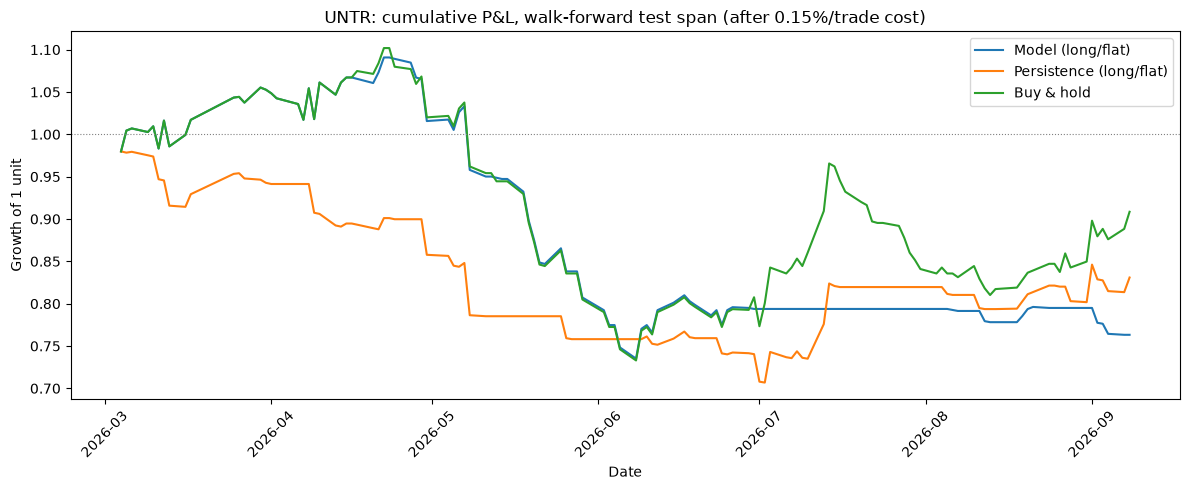

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
for col in curves.columns:
    ax.plot(curves.index, curves[col], label=col, linewidth=1.5)
ax.axhline(1.0, color="gray", linewidth=0.8, linestyle=":")
ax.set_ylabel("Growth of 1 unit")
ax.set_xlabel("Date")
ax.set_title(f"{TICKER}: cumulative P&L, walk-forward test span (after {COST_PER_TRADE:.2%}/trade cost)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# Which folds actually drove the model strategy's P&L? Isolates whether a
# positive total return is broad-based skill or one favorable stretch
# carrying the average -- the same check already needed for the accuracy numbers.
fold_pnl = model_ret.groupby(daily_df["fold"]).apply(lambda r: (1 + r).prod() - 1)
fold_pnl.name = "model_strategy_return"
print(fold_pnl.to_string())

fold
0    0.067127
1   -0.204714
2   -0.063278
3   -0.001500
4   -0.038480


### Reading this backtest

**UNTR: every strategy lost money over this test span, but the model lost the most.** Buy-and-hold: -9.1%. Persistence-driven long/flat: -16.9%. Model-driven long/flat: **-23.7%**, with the worst Sharpe-like ratio (-1.95) of the three. The model's 20 trades cost 3.0% in fees alone, and it still would have lost money before costs -- acting on this model's calls made things worse than doing nothing.

Per-fold P&L confirms the accuracy result wasn't a fluke: `fold_pnl` shows only fold 0 was profitable (+6.7%), and every other fold lost money, fold 1 badly (-20.5%). This matches the accuracy table almost exactly (fold 1 was also the model's worst accuracy fold, 28% vs persistence's 56%). There's no favorable stretch to point to here the way ASII has one -- UNTR's model is a consistent net negative, now confirmed at both the accuracy level and the money level.